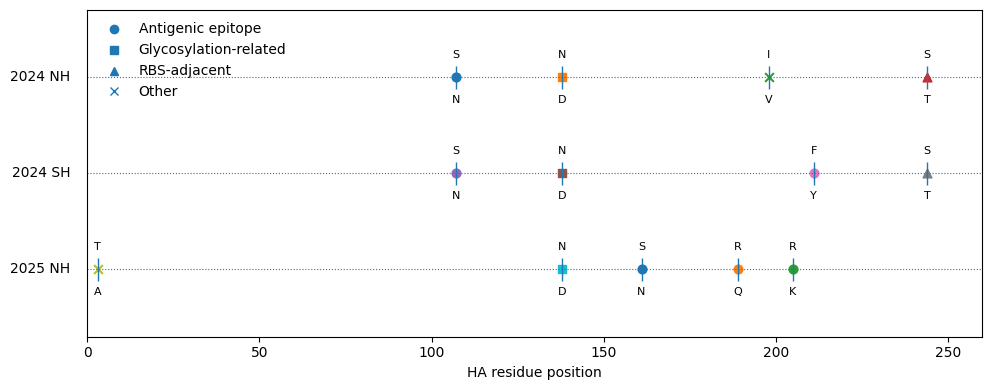

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ======================
# 1. 手动录入突变信息
# ======================
# 每条记录：
# pair   : 哪个配对（用于在 y 轴上分行）
# y      : 该配对在图上的纵向位置
# pos    : HA 氨基酸位置
# category: 功能类别（决定 marker 形状）
# who    : WHO 推荐毒株在该位点的氨基酸
# model  : 模型推荐毒株在该位点的氨基酸
pair_to_strains = {
    "2024 NH": ["A/Thailand/08/2022 EGG", "A/Albania/289813/2022 EGG"],
    "2024 SH": ["A/Massachusetts/18/2022 CELL", "A/Albania/289813/2022 EGG"],
    "2025 NH": ["A/France/IDF-IPP29542/2023 CELL", "Model: A/Croatia/10136RV/2023 CELL"],
}
mutations = [
    # 2024 NH: WHO A/Thailand/08/2022 EGG  vs  model A/Albania/289813/2022 EGG
    {"pair": "2024 NH", "y": 3, "pos": 107, "category": "epitope", "who": "S", "model": "N"},
    {"pair": "2024 NH", "y": 3, "pos": 138, "category": "glyco",   "who": "N", "model": "D"},
    {"pair": "2024 NH", "y": 3, "pos": 198, "category": "other",   "who": "I", "model": "V"},
    {"pair": "2024 NH", "y": 3, "pos": 244, "category": "RBS",     "who": "S", "model": "T"},

    # 2024 SH: WHO A/Massachusetts/18/2022 CELL vs model A/Albania/289813/2022 EGG
    {"pair": "2024 SH", "y": 2, "pos": 107, "category": "epitope", "who": "S", "model": "N"},
    {"pair": "2024 SH", "y": 2, "pos": 138, "category": "glyco",   "who": "N", "model": "D"},
    {"pair": "2024 SH", "y": 2, "pos": 211, "category": "epitope", "who": "F", "model": "Y"},
    {"pair": "2024 SH", "y": 2, "pos": 244, "category": "RBS",     "who": "S", "model": "T"},

    # 2025 NH: WHO A/FRANCE/IDF-IPP29542/2023 CELL vs model A/Croatia/10136RV/2023 CELL
    {"pair": "2025 NH", "y": 1, "pos": 3,   "category": "other",   "who": "T", "model": "A"},
    {"pair": "2025 NH", "y": 1, "pos": 138, "category": "glyco",   "who": "N", "model": "D"},
    {"pair": "2025 NH", "y": 1, "pos": 161, "category": "epitope", "who": "S", "model": "N"},
    {"pair": "2025 NH", "y": 1, "pos": 189, "category": "epitope", "who": "R", "model": "Q"},
    {"pair": "2025 NH", "y": 1, "pos": 205, "category": "epitope", "who": "R", "model": "K"},
]

# y 轴每一行对应的配对
y_levels = {"2024 NH": 3, "2024 SH": 2, "2025 NH": 1}

# ======================
# 2. 不同功能类别 → 不同 marker 形状
# ======================
category_to_marker = {
    "epitope": "o",  # 抗原表位
    "glyco":   "s",  # 糖基化相关
    "RBS":     "^",  # 受体结合位点附近
    "other":   "x",  # 其他
}

# ======================
# 3. 画图
# ======================
fig, ax = plt.subplots(figsize=(10, 4))

# 画每一行的水平虚线 + 左侧文字标签
for label, y in y_levels.items():
    ax.hlines(y, xmin=0, xmax=260, linestyles="dotted", linewidth=0.8)
    ax.text(-5, y, label, va="center", ha="right")  # 2024 NH / 2024 SH / 2025 NH
    # ax.text(10, y+0.2, pair_to_strains[label][0], va="center", ha="right")
    # ax.text(10, y-0.2, pair_to_strains[label][1], va="center", ha="right")

# 画每一个突变位点的小“棒棒糖”
for m in mutations:
    marker = category_to_marker.get(m["category"], "x")
    # 棒棒糖竖线（穿过虚线，向上/向下各延伸一点）
    # ax.vlines(m["pos"], m["y"] - 0.12, m["y"] + 0.12, linewidth=1)
    ax.vlines(m["pos"], m["y"] - 0.12, m["y"] + 0.12, linewidth=1)
    # 中间的 marker 表示突变类别
    ax.scatter(m["pos"], m["y"], marker=marker, s=40)
    # 虚线上方写 WHO 氨基酸
    ax.text(m["pos"], m["y"] + 0.18, m["who"],
            ha="center", va="bottom", fontsize=8)
    # 虚线下方写 模型推荐 氨基酸
    ax.text(m["pos"], m["y"] - 0.18, m["model"],
            ha="center", va="top", fontsize=8)




# 轴范围和标签
ax.set_ylim(0.3, 3.7)
ax.set_xlim(0, 260)           # 只画 head 的话可改成 (80, 260)
ax.set_xlabel("HA residue position")
ax.set_yticks([])             # y 轴刻度不要，用左侧手动标的文字

# ax.set_title("Amino acid differences between WHO and model-selected vaccine strains")

# ======================
# 4. 图例（根据 marker 形状手动做 legend）
# ======================
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='none', label='Antigenic epitope'),
    Line2D([0], [0], marker='s', linestyle='none', label='Glycosylation-related'),
    Line2D([0], [0], marker='^', linestyle='none', label='RBS-adjacent'),
    Line2D([0], [0], marker='x', linestyle='none', label='Other'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()

# 如需保存图像：
# plt.savefig("HA1_mutation_lollipop_AAlabels.png", dpi=300)
# plt.savefig("HA1_mutation_lollipop_AAlabels.pdf")

plt.show()

In [2]:
def read_fasta_minimal(path):
    records = {}
    header = None
    seq_lines = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records[header] = "".join(seq_lines)
                header = line[1:]   # 去掉 ">"
                seq_lines = []
            else:
                seq_lines.append(line)

    if header is not None:
        records[header] = "".join(seq_lines)

    return records

def diff_positions_1based(s1, s2):
    """
    返回: [(pos1, char_in_s1, char_in_s2), ...]
    """
    n = min(len(s1), len(s2))
    return [(i + 1, s1[i], s2[i]) for i in range(n) if s1[i] != s2[i]]

In [3]:
vaccine_strains = read_fasta_minimal('/home/chenyh/workspace/fluProfiler/paper/data/Fig2/vaccine_strain_sequences.fasta')
vaccine_strains = {key.split('|')[0]: value for key, value in vaccine_strains.items()}

In [4]:
diff_positions_1based(vaccine_strains['A/Albania/289813/2022'], 
                    vaccine_strains['A/Darwin/9/2021'])

[(3, 'A', 'T'),
 (66, 'K', 'E'),
 (69, 'N', 'D'),
 (107, 'N', 'S'),
 (112, 'S', 'N'),
 (138, 'D', 'N'),
 (156, 'K', 'I'),
 (202, 'D', 'N'),
 (208, 'F', 'I'),
 (211, 'Y', 'F'),
 (239, 'V', 'I'),
 (241, 'D', 'G'),
 (244, 'T', 'S'),
 (394, 'S', 'N')]

In [5]:
diff_positions_1based(vaccine_strains['A/Albania/289813/2022'],
                        vaccine_strains['A/Thailand/8/2022'])

[(107, 'N', 'S'), (138, 'D', 'N'), (198, 'V', 'I'), (244, 'T', 'S')]

## 1. egg-based vaccine strain

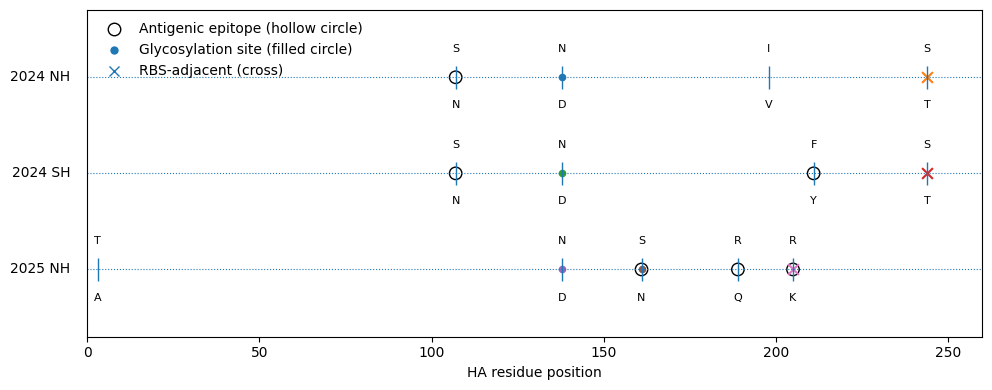

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ======================
# 1. 手动录入突变信息
# ======================
# category 可以是字符串或列表，例如 "epitope" 或 ["epitope", "glyco"]
mutations = [
    # 2024 NH: WHO A/Thailand/08/2022 EGG  vs  model A/Albania/289813/2022 EGG
    {"pair": "2024 NH", "y": 3, "pos": 107, "category": ["epitope"],          "who": "S", "model": "N"},
    {"pair": "2024 NH", "y": 3, "pos": 138, "category": ["glyco"],            "who": "N", "model": "D"},
    {"pair": "2024 NH", "y": 3, "pos": 198, "category": ["other"],            "who": "I", "model": "V"},
    {"pair": "2024 NH", "y": 3, "pos": 244, "category": ["RBS"],              "who": "S", "model": "T"},

    # 2024 SH: WHO A/Massachusetts/18/2022 CELL vs model A/Albania/289813/2022 EGG
    {"pair": "2024 SH", "y": 2, "pos": 107, "category": ["epitope"],          "who": "S", "model": "N"},
    {"pair": "2024 SH", "y": 2, "pos": 138, "category": ["glyco"],            "who": "N", "model": "D"},
    {"pair": "2024 SH", "y": 2, "pos": 211, "category": ["epitope"],          "who": "F", "model": "Y"},
    {"pair": "2024 SH", "y": 2, "pos": 244, "category": ["RBS"],              "who": "S", "model": "T"},

    # 2025 NH: WHO A/FRANCE/IDF-IPP29542/2023 CELL vs model A/Croatia/10136RV/2023 CELL
    {"pair": "2025 NH", "y": 1, "pos": 3,   "category": ["other"],            "who": "T", "model": "A"},
    {"pair": "2025 NH", "y": 1, "pos": 138, "category": ["glyco"],            "who": "N", "model": "D"},
    # 161 既在表位 A 又与糖位点邻近，示例多类别：
    {"pair": "2025 NH", "y": 1, "pos": 161, "category": ["epitope", "glyco"], "who": "S", "model": "N"},
    {"pair": "2025 NH", "y": 1, "pos": 189, "category": ["epitope"],          "who": "R", "model": "Q"},
    # 205 在 B 表位附近且靠近 RBS，示例 epitope + RBS：
    {"pair": "2025 NH", "y": 1, "pos": 205, "category": ["epitope", "RBS"],   "who": "R", "model": "K"},

] 

# 每一行对应的配对（用于画水平虚线和标签）
y_levels = {"2024 NH": 3, "2024 SH": 2, "2025 NH": 1}

# ======================
# 2. 画图
# ======================
fig, ax = plt.subplots(figsize=(10, 4))

# 画每一行的水平虚线 + 左侧文字
for label, y in y_levels.items():
    ax.hlines(y, xmin=0, xmax=260, linestyles="dotted", linewidth=0.8)
    ax.text(-5, y, label, va="center", ha="right")


for m in mutations:
    y = m["y"]
    x0 = m["pos"]

    # 支持 category 是字符串或列表
    cats = m["category"]
    if isinstance(cats, str):
        cats = [cats]

    # 中央竖线，表示该位点
    ax.vlines(x0, y - 0.12, y + 0.12, linewidth=1)

    # 先画空心大圆（表位），再画实心小圆（糖基化），避免被遮住
    if "epitope" in cats:
        ax.scatter(x0, y, s=80, facecolors='none', edgecolors='black')  # 空心大圆
    if "glyco" in cats:
        ax.scatter(x0, y, s=20)  # 实心小圆（用默认填充色）
    if "RBS" in cats:
        ax.scatter(x0, y, marker='x', s=60)

    # 上方写 WHO 氨基酸，下方写模型氨基酸
    ax.text(x0, y + 0.24, m["who"], ha="center", va="bottom", fontsize=8)
    ax.text(x0, y - 0.24, m["model"], ha="center", va="top",    fontsize=8)

# 轴范围和标签
ax.set_ylim(0.3, 3.7)
ax.set_xlim(0, 260)           # 如果只想画 head，可以改成 (80, 260)
ax.set_xlabel("HA residue position")
ax.set_yticks([])

# ax.set_title("Amino acid differences between WHO and model-selected vaccine strains")

# ======================
# 3. 图例：空心大圆 / 实心小圆 / 叉叉
# ======================
legend_elements = [
    Line2D([0], [0], marker='o', markersize=9,
           linestyle='none', markerfacecolor='none', markeredgecolor='black',
            label='Antigenic epitope (hollow circle)'),
    Line2D([0], [0], marker='o', markersize=5,
           linestyle='none', label='Glycosylation site (filled circle)'),
    Line2D([0], [0], marker='x', markersize=7,
           linestyle='none', label='RBS-adjacent (cross)'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
# plt.savefig("HA1_mutation_lollipop_circle_cross.png", dpi=300)
plt.show()
